In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, time, json, random, re
warnings.filterwarnings("ignore")

# ── NLTK ─────────────────────────────────────────────────────
import nltk
nltk.download("wordnet",                    quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("punkt",                      quiet=True)

# ── PyTorch ──────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# ── HuggingFace ──────────────────────────────────────────────
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_cosine_schedule_with_warmup
)

# ── Sklearn ──────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score,
    recall_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

# ── Augmentation ─────────────────────────────────────────────
import nlpaug.augmenter.word as naw

# ── Device setup ─────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED   = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
print(f"✅ Device : {DEVICE}")
print(f"✅ PyTorch: {torch.__version__}")
print(f"✅ NLTK   : {nltk.__version__}")
if DEVICE.type == "cuda":
    print(f"   GPU : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("   Running on CPU — training will take ~5-10 min per epoch")


✅ Device : cpu
✅ PyTorch: 2.6.0+cpu
✅ NLTK   : 3.9.3
   Running on CPU — training will take ~5-10 min per epoch


In [2]:
import os

# ── File path — update this if your CSV is in a different folder ──
CSV_PATH = 'dermatology_preprocessed_safe.csv'

# Verify file exists before loading
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(
        f'\n❌ File not found: {CSV_PATH}'
        f'\n   Please place dermatology_preprocessed_safe.csv in: {os.getcwd()}'
    )

df = pd.read_csv(CSV_PATH)
df['text'] = df['redacted_text'].astype(str).str.strip()

le = LabelEncoder()
df['label_id'] = le.fit_transform(df['label'])

NUM_CLASSES = df['label_id'].nunique()
CLASS_NAMES  = le.classes_.tolist()

print(f'✅ Dataset loaded from: {os.path.abspath(CSV_PATH)}')
print(f'   Rows        : {len(df)}')
print(f'   Classes     : {NUM_CLASSES}')
print(f'   Per class   : {df["label"].value_counts().unique()[0]} samples (balanced)')
print(f'   Avg text len: {df["text"].apply(len).mean():.0f} chars')
df[['text', 'label', 'label_id']].head(3)

✅ Dataset loaded from: c:\Users\User\OneDrive\Desktop\capstone_textdataset - Copy\dermatology_preprocessed_safe.csv
   Rows        : 330
   Classes     : 22
   Per class   : 15 samples (balanced)
   Avg text len: 149 chars


,text,label,label_id
0,i’ve been getting small red bumps on my cheeks...,acne,0
1,for [DATE] now i’ve noticed several painful bu...,acne,0
2,i keep getting tiny bumps on my forehead that ...,acne,0


In [3]:
X_train_raw, X_test_texts, y_train_raw, y_test = train_test_split(
    df['text'].tolist(),
    df['label_id'].tolist(),
    test_size=0.2,
    random_state=SEED,
    stratify=df['label_id'].tolist()
)

print(f"✅ Split (stratified 80/20)")
print(f"   Train (before aug): {len(X_train_raw)} | Test: {len(X_test_texts)}")
print(f"   Train per class   : ~{len(X_train_raw)//NUM_CLASSES}")
print(f"   Test  per class   : ~{len(X_test_texts)//NUM_CLASSES}")


✅ Split (stratified 80/20)
   Train (before aug): 264 | Test: 66
   Train per class   : ~12
   Test  per class   : ~3


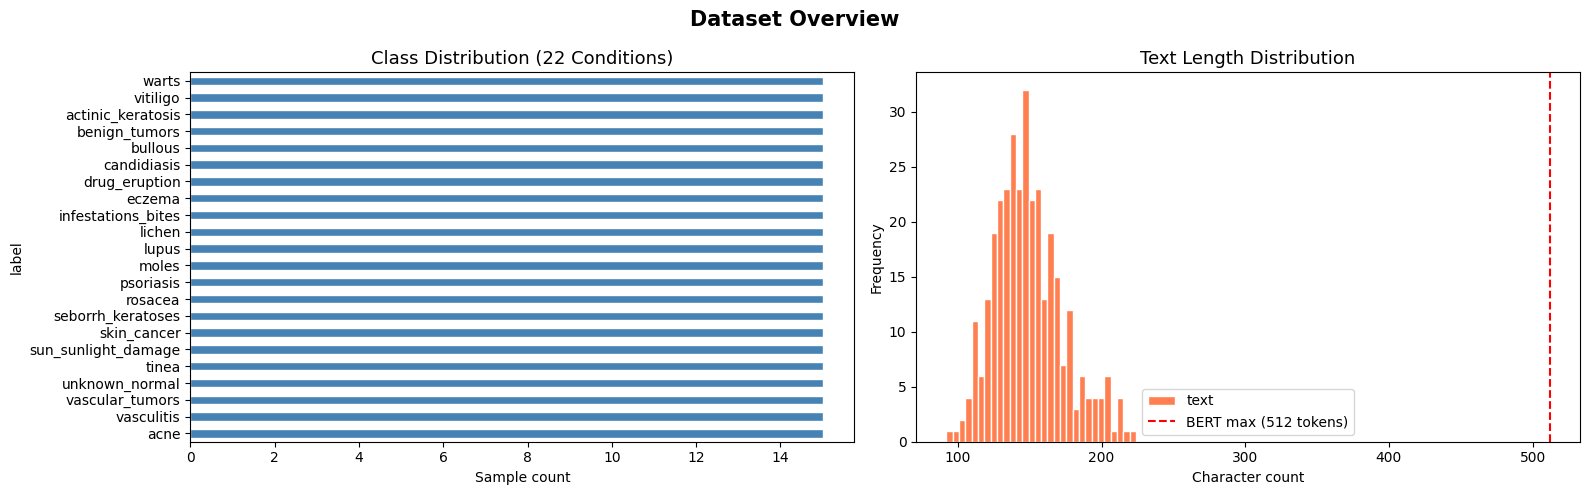

Min / Max / Mean text length: 92 / 224 / 149 chars


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df['label'].value_counts().sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Class Distribution (22 Conditions)', fontsize=13)
axes[0].set_xlabel('Sample count')

df['text'].apply(len).plot(
    kind='hist', bins=30, ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('Text Length Distribution', fontsize=13)
axes[1].set_xlabel('Character count')
axes[1].axvline(512, color='red', linestyle='--', label='BERT max (512 tokens)')
axes[1].legend()

plt.suptitle('Dataset Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Min / Max / Mean text length: '
      f'{df["text"].apply(len).min()} / '
      f'{df["text"].apply(len).max()} / '
      f'{df["text"].apply(len).mean():.0f} chars')

In [5]:
X_train_raw, X_test_texts, y_train_raw, y_test = train_test_split(
    df['text'].tolist(),
    df['label_id'].tolist(),
    test_size=0.2,
    random_state=SEED,
    stratify=df['label_id'].tolist()
)

print(f'✅ Split complete (stratified 80/20)')
print(f'   Train (before augmentation): {len(X_train_raw)} samples')
print(f'   Test                       : {len(X_test_texts)} samples')
print(f'   Train per class            : ~{len(X_train_raw)//NUM_CLASSES}')
print(f'   Test  per class            : ~{len(X_test_texts)//NUM_CLASSES}')

✅ Split complete (stratified 80/20)
   Train (before augmentation): 264 samples
   Test                       : 66 samples
   Train per class            : ~12
   Test  per class            : ~3


In [6]:
import nltk
nltk.download('wordnet',                    quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

syn_aug = naw.SynonymAug(aug_src='wordnet', aug_p=0.15)

def augment_deletion(text, p=0.1):
    words = text.split()
    if len(words) <= 4: return text
    kept = [w for w in words if random.random() > p]
    return ' '.join(kept) if len(kept) > 3 else text

def augment_swap(text, n_swaps=1):
    words = text.split()
    if len(words) < 3: return text
    for _ in range(n_swaps):
        i = random.randint(0, len(words)-2)
        words[i], words[i+1] = words[i+1], words[i]
    return ' '.join(words)

def augment_insert_filler(text):
    fillers = ['i think', 'i noticed', 'i feel like', 'it seems',
               'i believe', 'recently', 'sometimes', 'occasionally']
    words = text.split()
    if len(words) < 5: return text
    pos = random.randint(1, min(5, len(words)-1))
    words.insert(pos, random.choice(fillers))
    return ' '.join(words)

print('Running data augmentation (this takes ~2-3 minutes)...')
aug_texts, aug_labels = list(X_train_raw), list(y_train_raw)

for idx, (text, label) in enumerate(zip(X_train_raw, y_train_raw)):
    try:
        for _ in range(2):   # Synonym ×2
            aug = syn_aug.augment(text)
            aug_texts.append(str(aug[0] if isinstance(aug, list) else aug))
            aug_labels.append(label)
        for _ in range(2):   # Deletion ×2
            aug_texts.append(augment_deletion(text))
            aug_labels.append(label)
        for _ in range(2):   # Swap ×2
            aug_texts.append(augment_swap(text))
            aug_labels.append(label)
        aug_texts.append(augment_insert_filler(text))  # Filler ×1
        aug_labels.append(label)
    except Exception:
        pass

    if (idx+1) % 50 == 0:
        print(f'  Augmented {idx+1}/{len(X_train_raw)}...', end='\r')

X_train_texts = aug_texts
y_train       = aug_labels

print(f'\n✅ Augmentation complete')
print(f'   Before : {len(X_train_raw)} samples')
print(f'   After  : {len(X_train_texts)} samples ({len(X_train_texts)/len(X_train_raw):.1f}x)')
print(f'   Per class (approx): {len(X_train_texts)//NUM_CLASSES}')

Running data augmentation (this takes ~2-3 minutes)...
  Augmented 250/264...
✅ Augmentation complete
   Before : 264 samples
   After  : 2112 samples (8.0x)
   Per class (approx): 96


In [7]:
# BioBERT is pre-trained on PubMed + PMC medical text
# It understands medical vocabulary far better than standard BERT
MODEL_NAME = 'dmis-lab/biobert-base-cased-v1.2'
MAX_LEN    = 128

print(f'Loading tokenizer: {MODEL_NAME} ...')
print('(First run will download ~440MB from HuggingFace — saved to cache after)')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

lengths = [len(tokenizer.encode(t, add_special_tokens=True))
           for t in X_train_texts[:200]]
print(f'\n✅ Tokenizer ready')
print(f'   Token length — Mean: {np.mean(lengths):.1f} | '
      f'Max: {max(lengths)} | >128: {sum(l>128 for l in lengths)}')

Loading tokenizer: dmis-lab/biobert-base-cased-v1.2 ...
(First run will download ~440MB from HuggingFace — saved to cache after)

✅ Tokenizer ready
   Token length — Mean: 34.7 | Max: 51 | >128: 0


In [8]:
class SkinDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : enc['input_ids'].squeeze(0),
            'attention_mask' : enc['attention_mask'].squeeze(0),
            'labels'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Reduce BATCH_SIZE to 8 if you get out-of-memory errors
BATCH_SIZE = 16

train_dataset = SkinDataset(X_train_texts, y_train, tokenizer, MAX_LEN)
test_dataset  = SkinDataset(X_test_texts,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=(DEVICE.type=='cuda'))
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=(DEVICE.type=='cuda'))

print(f'✅ DataLoaders ready')
print(f'   Train batches : {len(train_loader)}')
print(f'   Test batches  : {len(test_loader)}')
print(f'   Batch size    : {BATCH_SIZE}')

✅ DataLoaders ready
   Train batches : 132
   Test batches  : 5
   Batch size    : 16


In [9]:
print(f'Loading {MODEL_NAME} ...')

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1
)
model = model.to(DEVICE)

# Class-weighted loss to handle any augmentation imbalance
cw = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train
)
class_weights = torch.tensor(cw, dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

total_params = sum(p.numel() for p in model.parameters())
print(f'✅ Model loaded')
print(f'   Parameters : {total_params:,}')
print(f'   Device     : {next(model.parameters()).device}')

Loading dmis-lab/biobert-base-cased-v1.2 ...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10201.25it/s]
BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture

✅ Model loaded
   Parameters : 108,327,190
   Device     : cpu


In [10]:
EPOCHS           = 20
LEARNING_RATE    = 1e-5
WARMUP_RATIO     = 0.15
GRAD_ACCUM_STEPS = 2
PATIENCE         = 4

no_decay  = ['bias', 'LayerNorm.weight']
optimizer = AdamW([
    {'params': [p for n,p in model.named_parameters()
                if not any(nd in n for nd in no_decay)], 'weight_decay': 0.01},
    {'params': [p for n,p in model.named_parameters()
                if     any(nd in n for nd in no_decay)], 'weight_decay': 0.0}
], lr=LEARNING_RATE)

total_steps  = (len(train_loader) // GRAD_ACCUM_STEPS) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

def evaluate(model, loader):
    model.eval()
    total_loss = correct = total = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids   = batch['input_ids'].to(DEVICE)
            mask  = batch['attention_mask'].to(DEVICE)
            labs  = batch['labels'].to(DEVICE)
            out   = model(input_ids=ids, attention_mask=mask)
            loss  = criterion(out.logits, labs)
            preds = out.logits.argmax(dim=-1)
            total_loss += loss.item()
            correct    += (preds == labs).sum().item()
            total      += labs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labs.cpu().numpy())
    return total_loss/len(loader), correct/total, all_preds, all_labels

history        = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
best_val_acc   = 0.0
best_model_wts = None
patience_ctr   = 0

print(f'{"="*65}')
print(f'  BioBERT Fine-Tuning')
print(f'  Epochs (max)    : {EPOCHS}  (early stopping patience={PATIENCE})')
print(f'  Learning rate   : {LEARNING_RATE}')
print(f'  Effective batch : {BATCH_SIZE * GRAD_ACCUM_STEPS}')
print(f'  Train samples   : {len(X_train_texts)}')
print(f'{"="*65}\n')

for epoch in range(1, EPOCHS+1):
    model.train()
    train_loss = train_correct = train_total = 0
    optimizer.zero_grad()
    t0 = time.time()

    for step, batch in enumerate(train_loader):
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        labs = batch['labels'].to(DEVICE)

        out  = model(input_ids=ids, attention_mask=mask)
        loss = criterion(out.logits, labs) / GRAD_ACCUM_STEPS
        loss.backward()

        preds          = out.logits.argmax(dim=-1)
        train_correct += (preds == labs).sum().item()
        train_total   += labs.size(0)
        train_loss    += loss.item() * GRAD_ACCUM_STEPS

        if (step+1) % GRAD_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

    avg_train_loss = train_loss / len(train_loader)
    train_acc      = train_correct / train_total
    val_loss, val_acc, _, _ = evaluate(model, test_loader)

    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    improved = ''
    if val_acc > best_val_acc:
        best_val_acc   = val_acc
        best_model_wts = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr   = 0
        improved       = '  ✅ best'
    else:
        patience_ctr  += 1

    print(f'  Ep {epoch:02d}/{EPOCHS} | '
          f'TrainLoss {avg_train_loss:.4f} | TrainAcc {train_acc:.4f} | '
          f'ValLoss {val_loss:.4f} | ValAcc {val_acc:.4f} | '
          f'{time.time()-t0:.1f}s{improved}')

    if patience_ctr >= PATIENCE:
        print(f'\n  ⏹  Early stopping at epoch {epoch}')
        break

print(f'\n  Best Val Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.1f}%)')

  BioBERT Fine-Tuning
  Epochs (max)    : 20  (early stopping patience=4)
  Learning rate   : 1e-05
  Effective batch : 32
  Train samples   : 2112

  Ep 01/20 | TrainLoss 3.1405 | TrainAcc 0.0587 | ValLoss 3.1266 | ValAcc 0.0606 | 1517.3s  ✅ best
  Ep 02/20 | TrainLoss 3.0347 | TrainAcc 0.0923 | ValLoss 3.0289 | ValAcc 0.2121 | 1493.2s  ✅ best
  Ep 03/20 | TrainLoss 2.6420 | TrainAcc 0.4309 | ValLoss 2.4877 | ValAcc 0.5000 | 1497.9s  ✅ best
  Ep 04/20 | TrainLoss 1.9507 | TrainAcc 0.8551 | ValLoss 1.8959 | ValAcc 0.7121 | 1490.2s  ✅ best
  Ep 05/20 | TrainLoss 1.3624 | TrainAcc 0.9725 | ValLoss 1.4407 | ValAcc 0.7576 | 1543.6s  ✅ best
  Ep 06/20 | TrainLoss 0.9758 | TrainAcc 0.9967 | ValLoss 1.2134 | ValAcc 0.8030 | 1559.6s  ✅ best
  Ep 07/20 | TrainLoss 0.7638 | TrainAcc 0.9995 | ValLoss 1.0050 | ValAcc 0.8333 | 1526.2s  ✅ best
  Ep 08/20 | TrainLoss 0.6624 | TrainAcc 1.0000 | ValLoss 0.9527 | ValAcc 0.8333 | 1459.5s
  Ep 09/20 | TrainLoss 0.6297 | TrainAcc 1.0000 | ValLoss 0.8769 | 

✅ Best model weights restored

  FINAL TEST RESULTS
  Metric                       Macro    Weighted
  ----------------------------------------------
  Accuracy                    87.88%   (overall)
  Precision                   0.9015      0.9015
  Recall                      0.8788      0.8788
  F1-Score                    0.8762      0.8762
  ----------------------------------------------
  Test Loss                   0.8769


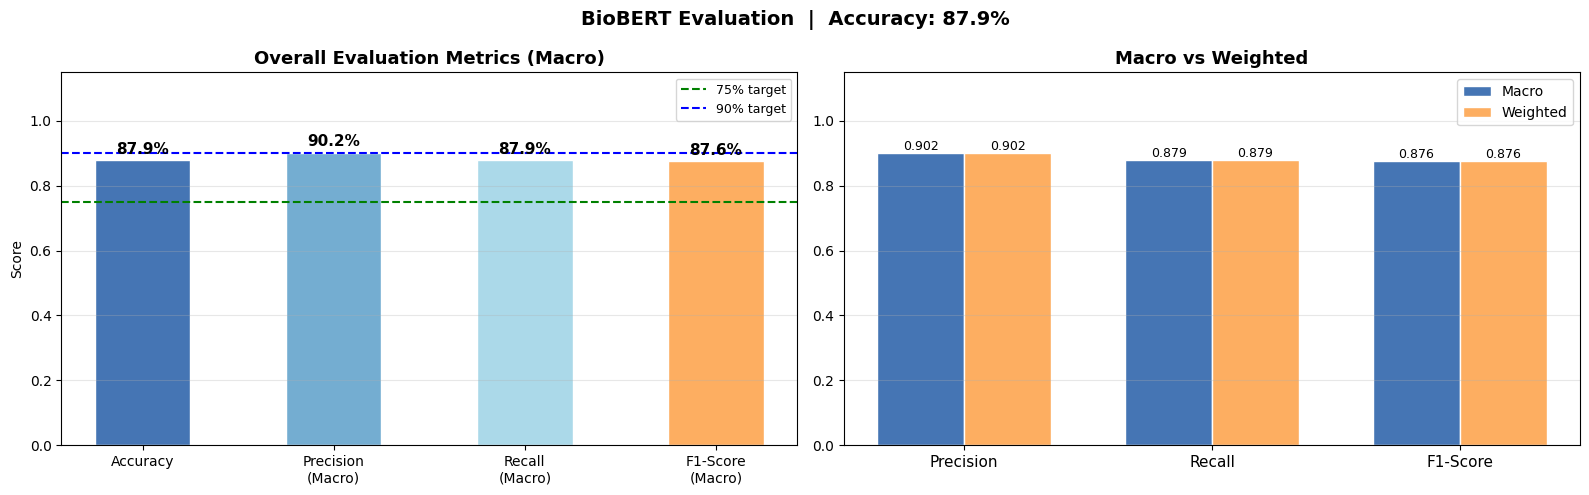

In [11]:
model.load_state_dict(best_model_wts)
print('✅ Best model weights restored')

test_loss, test_acc, test_preds, test_true = evaluate(model, test_loader)

accuracy           = accuracy_score(test_true, test_preds)
precision_macro    = precision_score(test_true, test_preds, average='macro',    zero_division=0)
precision_weighted = precision_score(test_true, test_preds, average='weighted', zero_division=0)
recall_macro       = recall_score(test_true,    test_preds, average='macro',    zero_division=0)
recall_weighted    = recall_score(test_true,    test_preds, average='weighted', zero_division=0)
f1_macro           = f1_score(test_true,        test_preds, average='macro',    zero_division=0)
f1_weighted        = f1_score(test_true,        test_preds, average='weighted', zero_division=0)

# ── Summary table ────────────────────────────────────────────
print(f'\n{"="*58}')
print(f'  FINAL TEST RESULTS')
print(f'{"="*58}')
print(f'  {"Metric":<22}  {"Macro":>10}  {"Weighted":>10}')
print(f'  {"-"*46}')
print(f'  {"Accuracy":<22}  {accuracy*100:>9.2f}%  {"(overall)":>10}')
print(f'  {"Precision":<22}  {precision_macro:>10.4f}  {precision_weighted:>10.4f}')
print(f'  {"Recall":<22}  {recall_macro:>10.4f}  {recall_weighted:>10.4f}')
print(f'  {"F1-Score":<22}  {f1_macro:>10.4f}  {f1_weighted:>10.4f}')
print(f'  {"-"*46}')
print(f'  {"Test Loss":<22}  {test_loss:>10.4f}')
print(f'{"="*58}')

# ── Bar chart ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

labels_bar = ['Accuracy', 'Precision\n(Macro)', 'Recall\n(Macro)', 'F1-Score\n(Macro)']
values_bar = [accuracy, precision_macro, recall_macro, f1_macro]
colors_bar = ['#4575b4', '#74add1', '#abd9e9', '#fdae61']

bars = axes[0].bar(labels_bar, values_bar, color=colors_bar, edgecolor='white', width=0.5)
axes[0].set_ylim(0, 1.15)
axes[0].axhline(0.75, color='green', linestyle='--', linewidth=1.5, label='75% target')
axes[0].axhline(0.90, color='blue',  linestyle='--', linewidth=1.5, label='90% target')
for bar, val in zip(bars, values_bar):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val*100:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Overall Evaluation Metrics (Macro)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

x     = np.arange(3)
width = 0.35
b1 = axes[1].bar(x - width/2, [precision_macro, recall_macro, f1_macro],
                  width, label='Macro',    color='#4575b4', edgecolor='white')
b2 = axes[1].bar(x + width/2, [precision_weighted, recall_weighted, f1_weighted],
                  width, label='Weighted', color='#fdae61', edgecolor='white')
for bar in list(b1)+list(b2):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Precision', 'Recall', 'F1-Score'], fontsize=11)
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Macro vs Weighted', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(f'BioBERT Evaluation  |  Accuracy: {accuracy*100:.1f}%',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


📊 Per-Class Evaluation Metrics (all 22 conditions):
───────────────────────────────────────────────────────────────────────────
Condition                     Accuracy  Precision   Recall  F1-Score  Support
───────────────────────────────────────────────────────────────────────────
  acne                          100.0%     1.0000   1.0000    1.0000      3.0
  actinic_keratosis             100.0%     1.0000   1.0000    1.0000      3.0
  benign_tumors                 100.0%     1.0000   1.0000    1.0000      3.0
  bullous                       100.0%     1.0000   1.0000    1.0000      3.0
  candidiasis                   100.0%     0.7500   1.0000    0.8571      3.0
  drug_eruption                  66.7%     0.6667   0.6667    0.6667      3.0
  eczema                        100.0%     1.0000   1.0000    1.0000      3.0
  infestations_bites            100.0%     0.7500   1.0000    0.8571      3.0
  lichen                         66.7%     1.0000   0.6667    0.8000      3.0
  lupus        

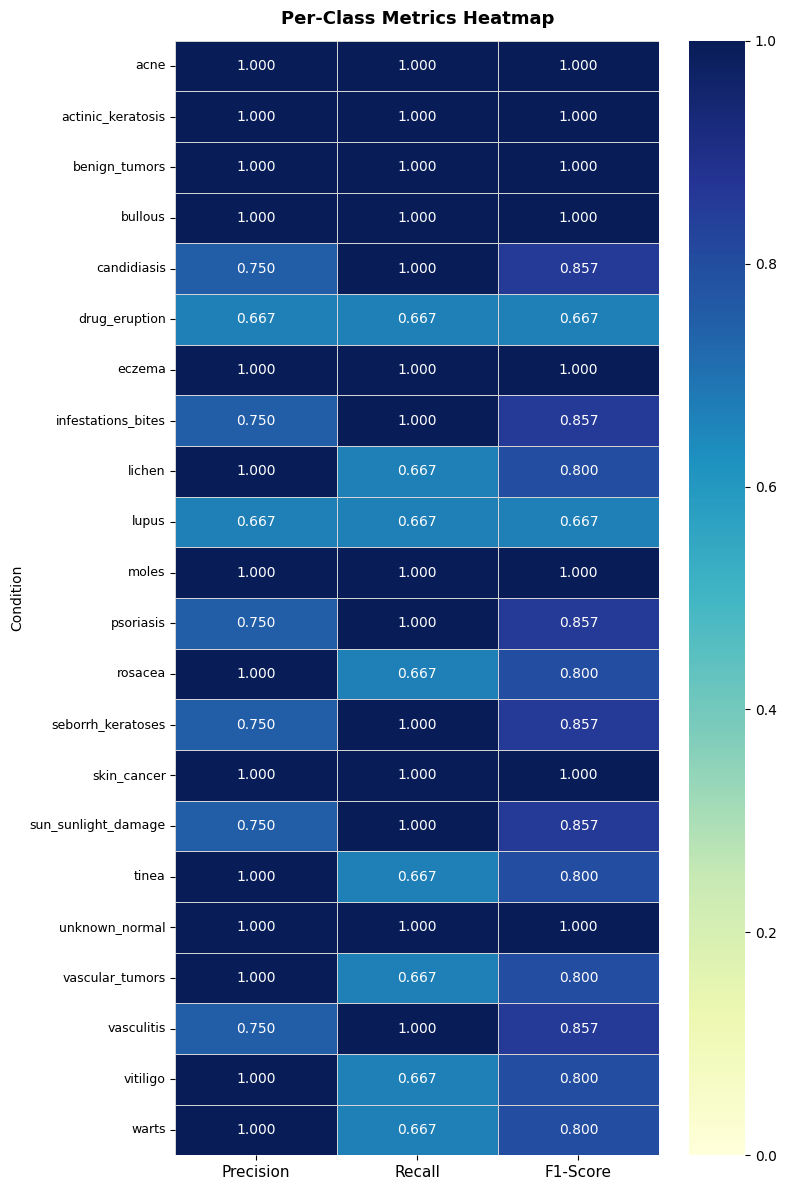

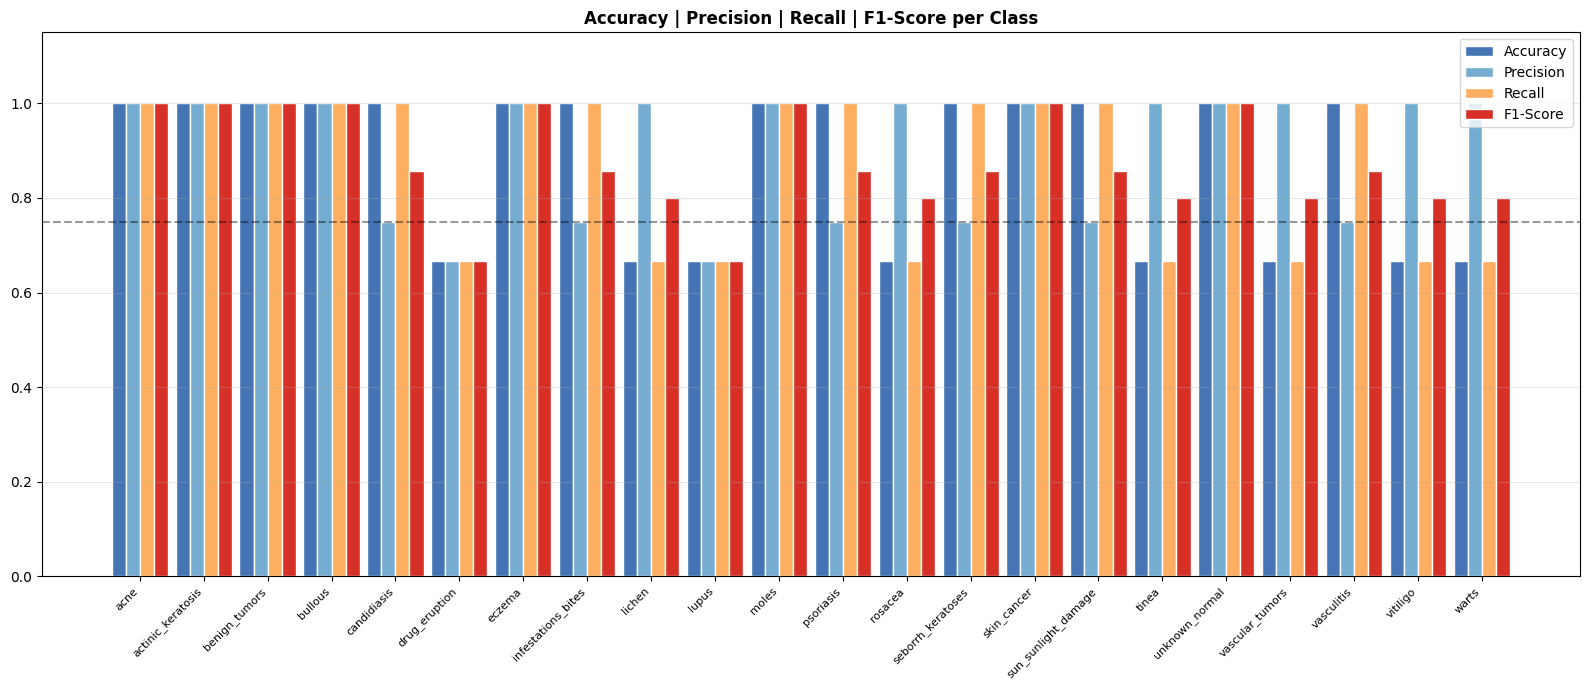

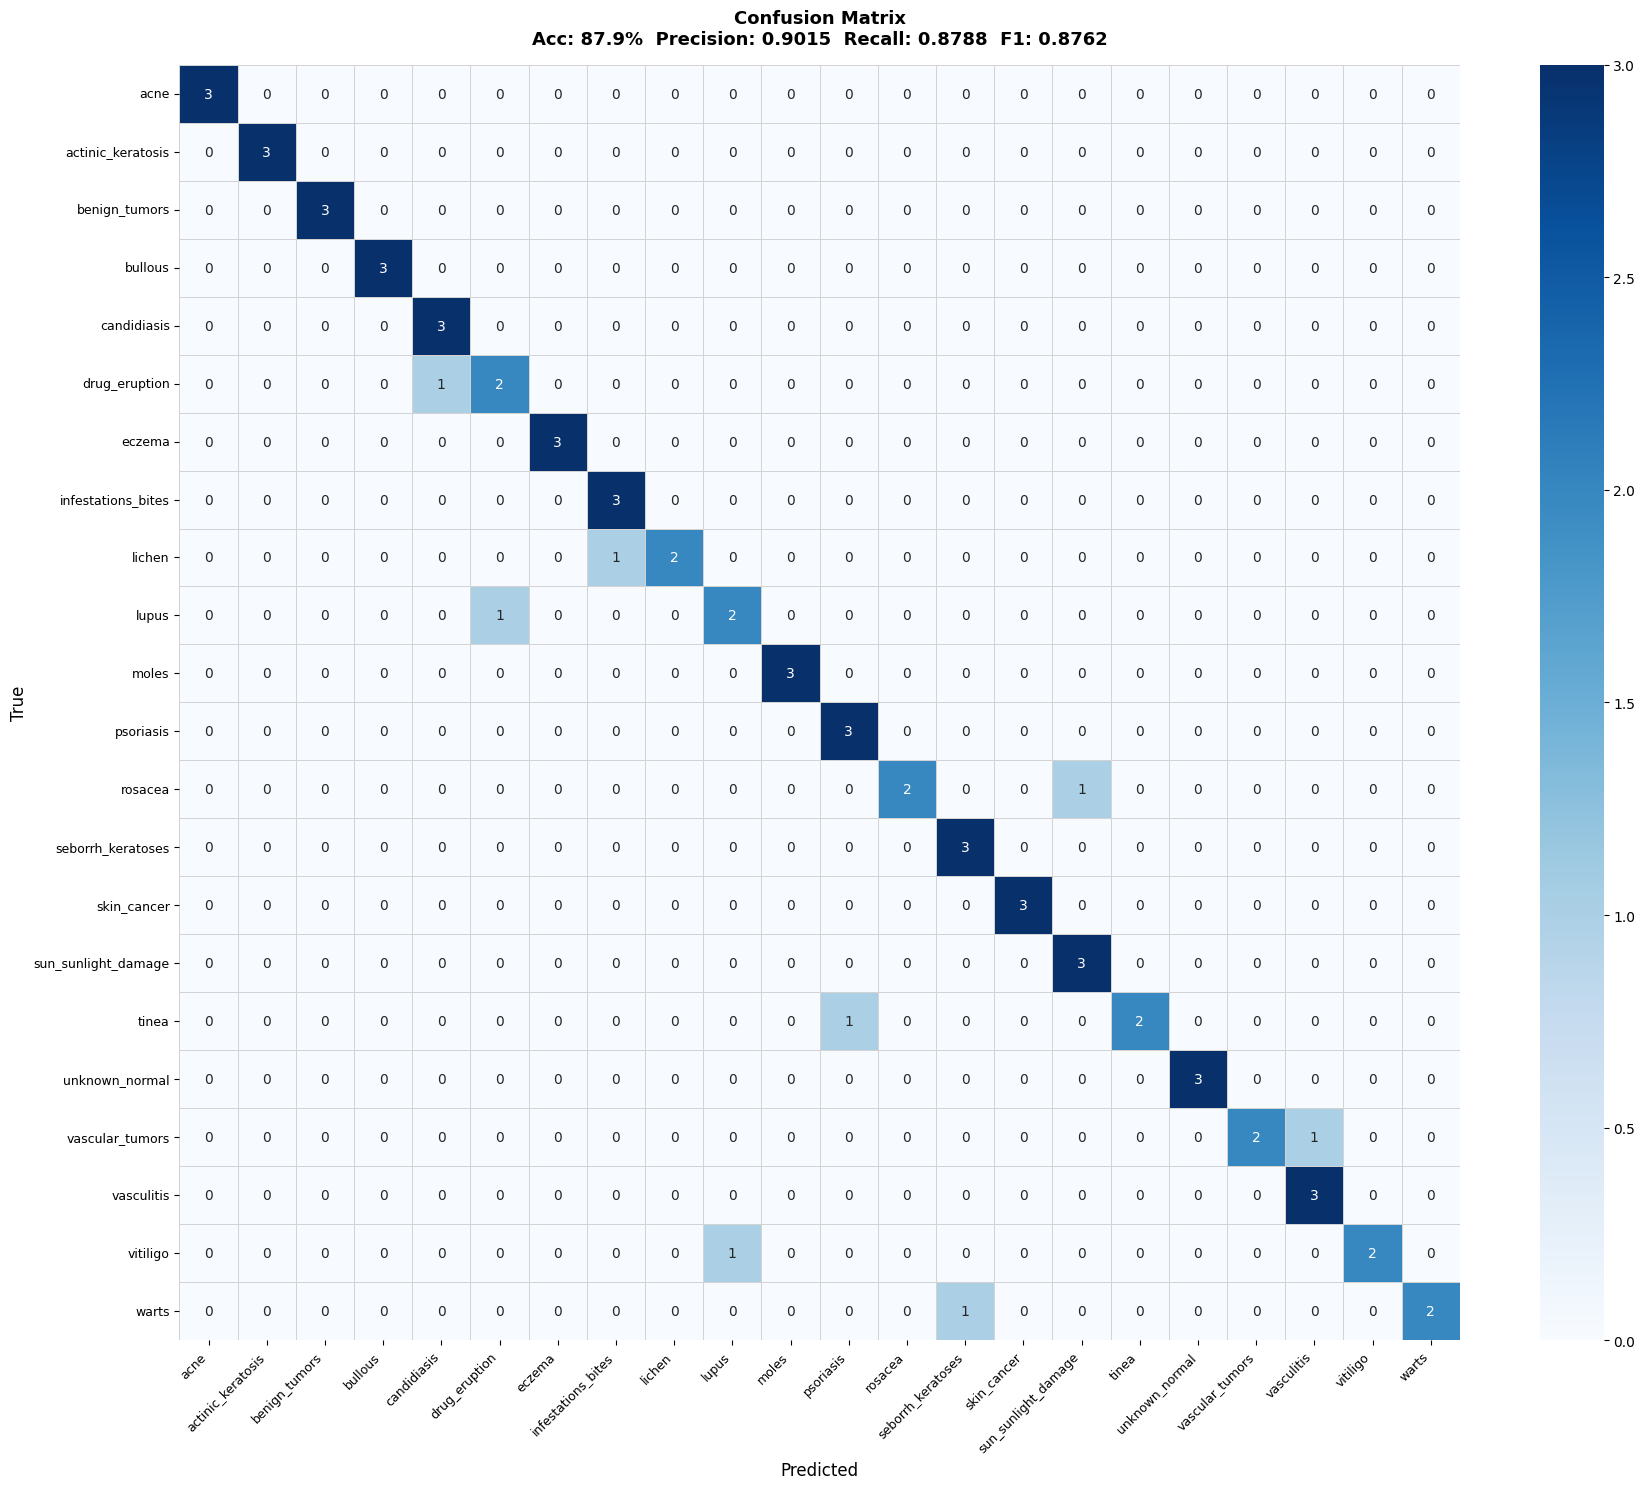

In [12]:
report_dict = classification_report(
    test_true, test_preds, target_names=CLASS_NAMES,
    digits=4, output_dict=True, zero_division=0
)

cm_raw = confusion_matrix(test_true, test_preds)

rows = []
for i, cls in enumerate(CLASS_NAMES):
    rows.append({
        'Condition' : cls,
        'Accuracy(%)'  : round(cm_raw[i,i] / cm_raw[i].sum() * 100, 1),
        'Precision' : round(report_dict[cls]['precision'], 4),
        'Recall'    : round(report_dict[cls]['recall'],    4),
        'F1-Score'  : round(report_dict[cls]['f1-score'],  4),
        'Support'   : int(report_dict[cls]['support'])
    })

per_class_df = pd.DataFrame(rows).set_index('Condition')

# Print table
print('\n📊 Per-Class Evaluation Metrics (all 22 conditions):')
print('─' * 75)
print(f'{"Condition":<28} {"Accuracy":>9} {"Precision":>10} {"Recall":>8} {"F1-Score":>9} {"Support":>8}')
print('─' * 75)
for idx, row in per_class_df.iterrows():
    print(f'  {idx:<26} {row["Accuracy(%)"]!s:>8}% '
          f'{row["Precision"]:>10.4f} '
          f'{row["Recall"]:>8.4f} '
          f'{row["F1-Score"]:>9.4f} '
          f'{row["Support"]:>8}')
print('─' * 75)
print(f'  {"MACRO AVG":<26} {accuracy*100:>8.1f}% '
      f'{precision_macro:>10.4f} '
      f'{recall_macro:>8.4f} '
      f'{f1_macro:>9.4f}')

# Save CSV to same folder as notebook
per_class_df.to_csv('evaluation_metrics_per_class.csv')
print(f'\n✅ Saved: evaluation_metrics_per_class.csv  →  {os.path.abspath("evaluation_metrics_per_class.csv")}')

# ── Per-class heatmap ────────────────────────────────────────
heatmap_data = per_class_df[['Precision','Recall','F1-Score']].astype(float)
plt.figure(figsize=(8, 12))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlGnBu',
            vmin=0, vmax=1, linewidths=0.5, linecolor='lightgray')
plt.title('Per-Class Metrics Heatmap', fontsize=13, fontweight='bold', pad=12)
plt.xticks(fontsize=11); plt.yticks(rotation=0, fontsize=9)
plt.tight_layout(); plt.show()

# ── Grouped 4-metric bar chart ────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))
x = np.arange(NUM_CLASSES); w = 0.22
ax.bar(x-1.5*w, per_class_df['Accuracy(%)']/100, w, label='Accuracy',  color='#4575b4', edgecolor='white')
ax.bar(x-0.5*w, per_class_df['Precision'],        w, label='Precision', color='#74add1', edgecolor='white')
ax.bar(x+0.5*w, per_class_df['Recall'],           w, label='Recall',    color='#fdae61', edgecolor='white')
ax.bar(x+1.5*w, per_class_df['F1-Score'],         w, label='F1-Score',  color='#d73027', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_ylim(0, 1.15); ax.axhline(0.75, color='black', linestyle='--', alpha=0.4)
ax.set_title('Accuracy | Precision | Recall | F1-Score per Class', fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# ── Confusion matrix ──────────────────────────────────────────
plt.figure(figsize=(18, 15))
sns.heatmap(cm_raw, annot=True, fmt='d',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cmap='Blues', linewidths=0.5, linecolor='lightgray')
plt.title(f'Confusion Matrix\nAcc: {accuracy*100:.1f}%  Precision: {precision_macro:.4f}  '
          f'Recall: {recall_macro:.4f}  F1: {f1_macro:.4f}',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Predicted', fontsize=12); plt.ylabel('True', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout(); plt.show()

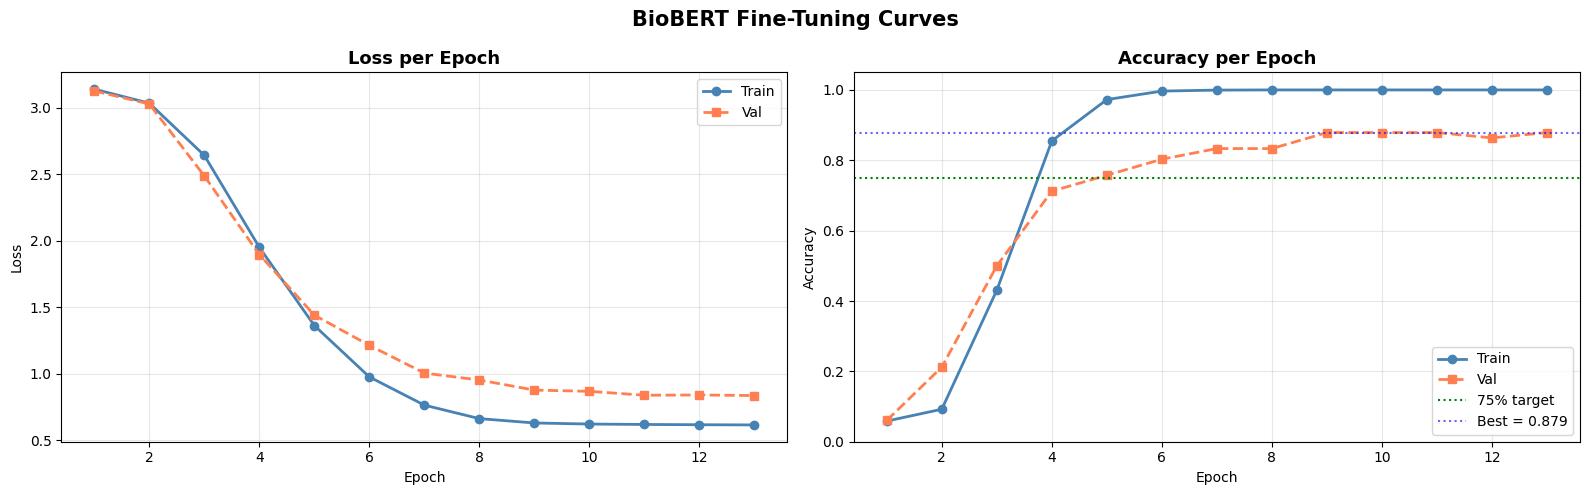

✅ Saved: training_curves.png  →  c:\Users\User\OneDrive\Desktop\capstone_textdataset - Copy\training_curves.png

Train/Val accuracy gap: 0.1212
✅ No strong signs of overfitting


In [13]:
ran = range(1, len(history['train_loss'])+1)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(ran, history['train_loss'], 'o-', color='steelblue', linewidth=2, label='Train')
axes[0].plot(ran, history['val_loss'],   's--', color='coral',    linewidth=2, label='Val')
axes[0].set_title('Loss per Epoch', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ran, history['train_acc'], 'o-', color='steelblue', linewidth=2, label='Train')
axes[1].plot(ran, history['val_acc'],   's--', color='coral',    linewidth=2, label='Val')
axes[1].axhline(0.75, color='green', linestyle=':', label='75% target')
axes[1].axhline(best_val_acc, color='blue', linestyle=':', alpha=0.6,
                label=f'Best = {best_val_acc:.3f}')
axes[1].set_title('Accuracy per Epoch', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('BioBERT Fine-Tuning Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: training_curves.png  →  {os.path.abspath("training_curves.png")}')

gap = max(history['train_acc']) - history['val_acc'][-1]
print(f'\nTrain/Val accuracy gap: {gap:.4f}')
if gap > 0.15: print('⚠️  Possible overfitting')
else:          print('✅ No strong signs of overfitting')

In [14]:
def predict(text, top_k=5):
    model.eval()
    enc = tokenizer(text, max_length=MAX_LEN, padding='max_length',
                    truncation=True, return_tensors='pt')
    with torch.no_grad():
        logits = model(enc['input_ids'].to(DEVICE),
                       enc['attention_mask'].to(DEVICE)).logits
        probs  = torch.softmax(logits, dim=-1).squeeze(0)
    top_p, top_i = torch.topk(probs, k=top_k)
    top_labels   = le.inverse_transform(top_i.cpu().numpy())
    return {
        'predicted'  : top_labels[0],
        'confidence' : top_p[0].item(),
        'top_k'      : list(zip(top_labels, top_p.cpu().numpy()))
    }

cases = [
    'I have small red bumps on my cheeks and forehead that feel sore with white tips.',
    'Rough scaly patches on my scalp that feel dry and itchy for several months.',
    'White patches spreading slowly across my arms with no pain.',
    'Very itchy raised red patches that come and go, skin feels dry and cracked.',
    'Small painless lump under the skin on my arm slowly growing over 6 months.'
]

print('='*65)
print('  INFERENCE DEMO')
print('='*65)
for i, text in enumerate(cases, 1):
    r = predict(text)
    print(f'\nCase {i}: "{text[:70]}..."')
    print(f'  → Predicted : {r["predicted"].upper()}  ({r["confidence"]*100:.1f}%)')
    print(f'  → Top-5:')
    for label, prob in r['top_k']:
        bar = '█' * int(prob*25)
        print(f'       {label:<25} {prob*100:5.1f}%  {bar}')

  INFERENCE DEMO

Case 1: "I have small red bumps on my cheeks and forehead that feel sore with w..."
  → Predicted : ACNE  (89.4%)
  → Top-5:
       acne                       89.4%  ██████████████████████
       lichen                      1.4%  
       vasculitis                  1.4%  
       warts                       0.9%  
       vascular_tumors             0.8%  

Case 2: "Rough scaly patches on my scalp that feel dry and itchy for several mo..."
  → Predicted : PSORIASIS  (75.6%)
  → Top-5:
       psoriasis                  75.6%  ██████████████████
       lupus                       3.9%  
       tinea                       3.4%  
       eczema                      3.0%  
       actinic_keratosis           2.2%  

Case 3: "White patches spreading slowly across my arms with no pain...."
  → Predicted : LUPUS  (29.6%)
  → Top-5:
       lupus                      29.6%  ███████
       vitiligo                   18.3%  ████
       vasculitis                  8.5%  ██
       tine

In [15]:
import shutil

SAVE_DIR = 'biobert_skin_model'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save model weights + config + tokenizer
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Save label mapping
with open(f'{SAVE_DIR}/label_mapping.json', 'w') as f:
    json.dump({int(i): n for i, n in enumerate(CLASS_NAMES)}, f, indent=2)

# Save training history
pd.DataFrame(history).to_csv(f'{SAVE_DIR}/training_history.csv', index=False)

# Save metrics
per_class_df.to_csv(f'{SAVE_DIR}/evaluation_metrics_per_class.csv')

# Zip the folder
shutil.make_archive(SAVE_DIR, 'zip', SAVE_DIR)

print(f'✅ Model saved to folder: {os.path.abspath(SAVE_DIR)}')
print(f'✅ Zip file created     : {os.path.abspath(SAVE_DIR + ".zip")}')
print(f'\nFiles saved:')
for f in os.listdir(SAVE_DIR):
    size = os.path.getsize(f'{SAVE_DIR}/{f}') / 1e6
    print(f'  {f:<45} {size:.1f} MB')

print(f'\n{"="*55}')
print(f'  FINAL SUMMARY')
print(f'{"="*55}')
print(f'  Model        : BioBERT (dmis-lab/biobert-base-cased-v1.2)')
print(f'  Train samples: {len(X_train_texts)} (augmented from {len(X_train_raw)})')
print(f'  Test samples : {len(X_test_texts)}')
print(f'  Best Val Acc : {best_val_acc*100:.1f}%')
print(f'  Test Accuracy: {accuracy*100:.1f}%')
print(f'  Precision    : {precision_macro:.4f} (macro)')
print(f'  Recall       : {recall_macro:.4f} (macro)')
print(f'  F1-Score     : {f1_macro:.4f} (macro)')
print(f'{"="*55}')

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.81s/it]


✅ Model saved to folder: c:\Users\User\OneDrive\Desktop\capstone_textdataset - Copy\biobert_skin_model
✅ Zip file created     : c:\Users\User\OneDrive\Desktop\capstone_textdataset - Copy\biobert_skin_model.zip

Files saved:
  config.json                                   0.0 MB
  evaluation_metrics_per_class.csv              0.0 MB
  label_mapping.json                            0.0 MB
  model.safetensors                             433.3 MB
  tokenizer.json                                0.7 MB
  tokenizer_config.json                         0.0 MB
  training_history.csv                          0.0 MB

  FINAL SUMMARY
  Model        : BioBERT (dmis-lab/biobert-base-cased-v1.2)
  Train samples: 2112 (augmented from 264)
  Test samples : 66
  Best Val Acc : 87.9%
  Test Accuracy: 87.9%
  Precision    : 0.9015 (macro)
  Recall       : 0.8788 (macro)
  F1-Score     : 0.8762 (macro)
